# Mob-Res plant-disease classifier — checkpoint validation on the author's PlantVillage split

**Paper:** A lightweight and explainable CNN model for empowering plant disease diagnosis — C. Pal, S. Karmakar, I. Mukherjee, P. P. Chakrabarti, Scientific Reports 15, 30720 (2025), DOI 10.1038/s41598-025-94083-1

**Author code:** [Chiranjit369/Mob-Res](https://github.com/Chiranjit369/Mob-Res) @ commit `36d469b04fc3d3da58bb2cfdf89d4160ac38db01`
(README, `Mob-Res_Validation.ipynb`, `Mob-Res_Code.ipynb`, checkpoint `Mob-Res_(A+B)Bf_config.keras`, `PlantVillage Validation/` — 10,861 images, 38 classes).

**Scope (executed):** load the authors' released **(A+B)Bf** checkpoint (trained on Plant Disease Expert + PlantVillage, fine-tuned on PlantVillage) and validate it on the authors' bundled 10,861-image PlantVillage validation split, following the authors' own `Mob-Res_Validation.ipynb` procedure (128×128 input, `shuffle=False`, batch 16, confusion matrix, overall accuracy, macro precision/recall). Reference value from the paper: **99.92% accuracy** for (A+B)Bf on PlantVillage. A single-image **Grad-CAM** demo on the paper's named layers (Path1 layer-27 ReLU, Path2 `out_relu`) is included as a re-implementation.

**Out of scope:** retraining, the other seven training configurations, the Kaggle-gated Plant Disease Expert dataset, the sugarcane field experiment, and benchmark comparisons.

**実行内容（日本語）:** 論文著者公開の (A+B)Bf 学習済みチェックポイントを、著者同梱の PlantVillage 検証用 10,861 枚（38 クラス）で、著者自身の `Mob-Res_Validation.ipynb` 手順（128×128、shuffle=False、バッチ 16、混同行列・正解率・マクロ適合率/再現率）に従って検証します。論文参照値は 99.92%。論文が名指しする層（Path1 第 27 層 ReLU、Path2 `out_relu`）での Grad-CAM の再実装デモを 1 例だけ含めます。再学習・他構成・Kaggle データセット・サトウキビ実験は対象外です。

**AI-assisted compatibility note / AI による互換対応:** The authors did not provide this Colab notebook. The validation procedure is copied from the authors' `Mob-Res_Validation.ipynb`; the runtime adaptations (installing `tf-keras` for the legacy-Keras checkpoint, renaming the misnamed `.keras` HDF5 file, and the Grad-CAM re-implementation) are AI-generated and were validated by execution. *著者はこの Colab 実装を提供していません。検証手順は著者のノートブックからの写しですが、レガシーチェックポイント用の `tf-keras` 導入や誤名拡張子の修正、Grad-CAM 再実装は AI が追加した適応であり、実行によって検証済みです。*


## Runtime selection / ランタイム選択

**Recommended: Google Colab T4 GPU** (Edit ▸ Notebook settings ▸ T4 GPU). A CPU runtime also works — the notebook has no hardware-specific cells; TensorFlow uses the GPU automatically when present, and CPU only takes longer for the 10,861-image pass.

**推奨は T4 GPU です。** CPU でも動作します（コードに GPU 専用部分はなく、TensorFlow が自動で GPU を使用します）。CPU の場合は 10,861 枚の推論に時間がかかるだけです。

Expected: ~185 MB download (validation images + 14.9 MB checkpoint), ~10–20 min end-to-end on T4 (CPU: tens of minutes). / 目安: 約 185 MB のダウンロード、T4 で 10–20 分程度（CPU ではさらに長め）。


### Environment check

Report the Python/TensorFlow versions and whether a GPU is attached, so the validation record states the actual hardware. **環境確認:** 実際のハードウェアを記録するため Python/TensorFlow のバージョンと GPU の有無を表示します。


In [ ]:
import platform, sys
print("python", platform.python_version())
import tensorflow as tf
print("tensorflow", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
print("Runtime is", "GPU (T4-class)" if gpus else "CPU")


python 3.13.15


tensorflow 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Runtime is GPU (T4-class)


### Legacy checkpoint support

The authors list "TensorFlow 2.10 / Keras 2.10", but Colab ships Keras 3, and the released checkpoint is a **legacy Keras-2 HDF5 file** (it begins with the HDF5 magic, despite its `.keras` name). We install `tf-keras` (the Keras-2 compatibility package) and load the checkpoint through the Keras-2 lineage API. **レガシー対応:** 配布チェックポイントは実際には HDF5 形式（Keras 2 系）のため、`tf-keras` を導入して Keras 2 系 API で読み込みます。


In [ ]:
import subprocess, sys
r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tf-keras"],
                   capture_output=True, text=True)
print(r.stdout[-500:] if r.stdout else "pip: quiet ok")
import tf_keras
print("tf_keras", tf_keras.__version__)


pip: quiet ok


tf_keras 2.21.0


### Data acquisition — pinned partial clone (inside Colab only)

Clone the author repository **blob-free and sparse**, fetching only the exact verified commit `36d469b…`, and check out just the checkpoint and `PlantVillage Validation/` (10,861 JPGs, 38 class folders, ≈185 MB). The checked-out commit is asserted. **データ取得:** 著者リポジトリを blob なし・スパースチェックアウトでピン留めコミット `36d469b…` だけ取得します（チェックポイント + 検証画像 10,861 枚）。コミット一致を検証します。


In [ ]:
import subprocess, os, glob, shutil

REPO = "https://github.com/Chiranjit369/Mob-Res"
PIN = "36d469b04fc3d3da58bb2cfdf89d4160ac38db01"
DST = "/content/mobres"

def sh(*args):
    r = subprocess.run(args, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(r.stderr[-800:])
    return r.stdout.strip()

if not os.path.exists(DST):
    sh("git", "init", "-q", DST)
    sh("git", "-C", DST, "remote", "add", "origin", REPO)
    sh("git", "-C", DST, "config", "extensions.partialclone", "origin")
    sh("git", "-C", DST, "sparse-checkout", "init", "--cone")
    sh("git", "-C", DST, "sparse-checkout", "set",
       "PlantVillage Validation", "Mob-Res_(A+B)Bf_config.keras")
    sh("git", "-C", DST, "fetch", "-q", "--depth=1", "--filter=blob:none", "origin", PIN)
    sh("git", "-C", DST, "checkout", "-q", "FETCH_HEAD")

head = sh("git", "-C", DST, "rev-parse", "HEAD")
assert head == PIN, f"checked-out commit {head} != pinned {PIN}"
print("HEAD == pinned commit OK")

files = glob.glob(os.path.join(DST, "PlantVillage Validation", "**", "*.*"), recursive=True)
print("validation files:", len(files))
assert len(files) == 10861
classes = sorted(os.listdir(os.path.join(DST, "PlantVillage Validation")))
print("classes:", len(classes))
ckpt = os.path.join(DST, "Mob-Res_(A+B)Bf_config.keras")
print("checkpoint bytes:", os.path.getsize(ckpt))
assert os.path.getsize(ckpt) == 14899232


HEAD == pinned commit OK
validation files: 10861
classes: 38
checkpoint bytes: 14899232


### Build the validation dataset exactly as the authors do

The authors' `Mob-Res_Validation.ipynb` uses `image_dataset_from_directory` with `image_size=(128,128)`, `batch_size=16`, `shuffle=False` — labels come from the folder names in alphabetical order. No extra rescaling is applied; any preprocessing lives inside the checkpoint. **データセット構築:** 著者のセルと同一の設定（128×128・バッチ 16・shuffle=False）で `image_dataset_from_directory` を使用します。前処理はチェックポイント内部に含まれます。


In [ ]:
import tf_keras
VAL_DIR = "/content/mobres/PlantVillage Validation"
val_ds = tf_keras.utils.image_dataset_from_directory(
    VAL_DIR,
    batch_size=16,
    image_size=(128, 128),
    shuffle=False,
)
class_names = val_ds.class_names
print("n_classes:", len(class_names))
print("first:", class_names[0], "| last:", class_names[-1])
assert len(class_names) == 38


Found 10861 files belonging to 38 classes.


n_classes: 38
first: Apple___Apple_scab | last: Tomato___healthy


### Load the released checkpoint

The `.keras` file is actually legacy HDF5 (verified by its `\x89HDF` magic and its Keras-2 serialization); we copy it to an `.h5` name and load it with `tf_keras`. We verify the parameter count against the paper's 3.51M. **チェックポイント読み込み:** `.keras` 名の実体はレガシー HDF5 なので `.h5` 名でコピーし `tf_keras` で読み込みます。論文の 3.51M パラメータと一致することを確認します。


In [ ]:
import hashlib, shutil

raw = open("/content/mobres/Mob-Res_(A+B)Bf_config.keras", "rb").read()
print("magic:", raw[:4], "| sha256:", hashlib.sha256(raw).hexdigest())
assert raw[:4] == b"\x89HDF"
h5_path = "/content/mobres/Mob-Res_(A+B)Bf_config.h5"
shutil.copy("/content/mobres/Mob-Res_(A+B)Bf_config.keras", h5_path)

model = tf_keras.models.load_model(h5_path)
print("input:", model.input_shape, "| output:", model.output_shape)
n_params = model.count_params()
print("parameters:", n_params)
assert model.input_shape[1:] == (128, 128, 3)
assert model.output_shape[-1] == 38
assert 3_500_000 < n_params < 3_520_000  # paper: 3.51M


magic: b'\x89HDF' | sha256: aae879a02e93f1842bbaac865085abc8b5f03d3fc657ef02a3cf084cb138f8d4


input: (None, 128, 128, 3) | output: (None, 38)
parameters: 3508774


### Input preview (before any analysis)

Show the first 8 images of the validation split with their **ground-truth folder labels** — the actual classifier inputs (128×128 RGB PlantVillage leaves). **入力プレビュー:** 解析前に検証分割の先頭 8 枚を正解ラベル付きで表示します（分類器への実際の入力）。


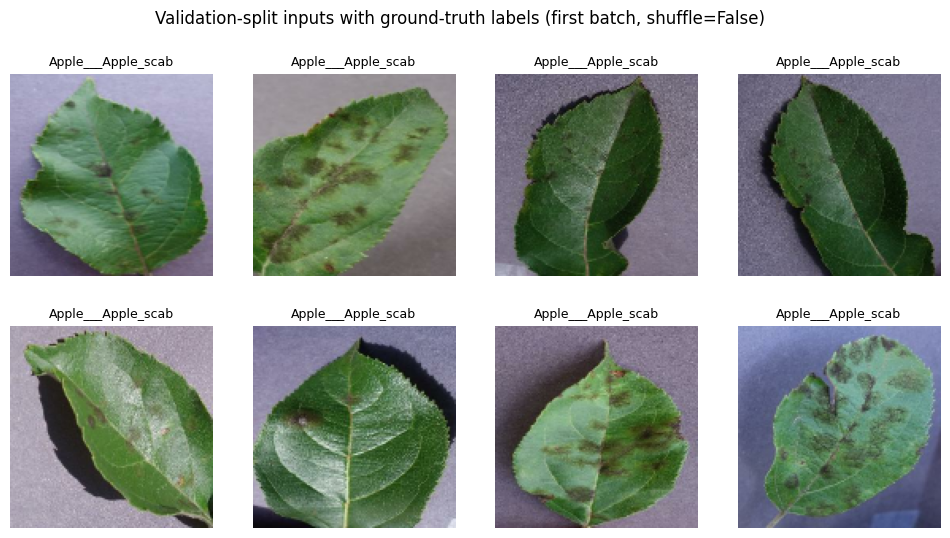

In [ ]:
import matplotlib.pyplot as plt

imgs, labs = next(iter(val_ds))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lab in zip(axes.ravel(), imgs, labs):
    ax.imshow(img.numpy().astype("uint8"))
    ax.set_title(class_names[int(lab)], fontsize=9)
    ax.axis("off")
fig.suptitle("Validation-split inputs with ground-truth labels (first batch, shuffle=False)")
plt.show()


### Sanity check — first-batch predictions

Predict the first batch and compare predicted vs. true class names, before running the full pass. **サニティチェック:** 全体検証の前に最初のバッチで予測と正解を比較します。


In [ ]:
import numpy as np
batch_pred = model.predict(imgs, verbose=0)
print("batch output shape:", batch_pred.shape,
      "| row sums 0-1:", bool(np.all((batch_pred.sum(1) > 0.99) & (batch_pred.sum(1) < 1.01))))
for i in range(8):
    print(f"{i}: true={class_names[int(labs[i])]:<50s} pred={class_names[int(batch_pred[i].argmax())]:<50s} p={batch_pred[i].max():.4f}")


batch output shape: (16, 38) | row sums 0-1: True
0: true=Apple___Apple_scab                                 pred=Apple___Apple_scab                                 p=1.0000
1: true=Apple___Apple_scab                                 pred=Apple___Apple_scab                                 p=1.0000
2: true=Apple___Apple_scab                                 pred=Apple___Apple_scab                                 p=0.9859
3: true=Apple___Apple_scab                                 pred=Apple___Apple_scab                                 p=0.9974
4: true=Apple___Apple_scab                                 pred=Apple___Apple_scab                                 p=0.9999
5: true=Apple___Apple_scab                                 pred=Apple___Apple_scab                                 p=0.9998
6: true=Apple___Apple_scab                                 pred=Apple___Apple_scab                                 p=1.0000
7: true=Apple___Apple_scab                                 pred=Apple___Apple_scab

### Full validation pass (authors' procedure)

`model.predict(val_ds)` over all 10,861 images with `shuffle=False`, exactly as in `Mob-Res_Validation.ipynb`. On T4 this takes a few minutes; on CPU tens of minutes. **全体検証:** 著者のノートブックと同じく shuffle=False のまま全 10,861 枚を推論します。T4 で数分、CPU では数十分です。


In [ ]:
import time
t0 = time.time()
pred_proba = model.predict(val_ds, verbose=1)
elapsed = time.time() - t0
pred = np.argmax(pred_proba, axis=1)
print("pred.shape:", pred.shape, f"| elapsed: {elapsed:.1f}s")


  1/679 [..............................] - ETA: 13:41

  2/679 [..............................] - ETA: 1:14 

  3/679 [..............................] - ETA: 1:16

  4/679 [..............................] - ETA: 1:13

  5/679 [..............................] - ETA: 1:12

...

677/679 [============================>.] - ETA: 0s

678/679 [============================>.] - ETA: 0s

679/679 [==============================] - ETA: 0s

679/679 [==============================] - 74s 108ms/step


pred.shape: (10861,) | elapsed: 75.0s


### Ground-truth labels and confusion matrix

Collect the dataset labels in order and build the 38×38 confusion matrix with the authors' convention (rows = predicted, columns = true). **混同行列:** データセットのラベルを順に収集し、著者の規約（行=予測、列=正解）で 38×38 の混同行列を作成します。


In [ ]:
lab = []
for _, i in val_ds:
    for j in i:
        lab.append(j)
lab = np.asarray(lab)
print("lab.shape:", lab.shape)

cm = np.zeros((len(class_names), len(class_names)), int)
for i in range(len(lab)):
    cm[pred[i]][lab[i]] += 1
print("total samples:", cm.sum())


lab.shape: (10861,)
total samples: 10861


### Overall accuracy vs. the paper's 99.92%

The authors compute accuracy as the confusion-matrix diagonal over the total. The paper reports **99.92%** for the (A+B)Bf configuration on PlantVillage. **正解率:** 著者の定義（対角成分/総数）で計算し、論文の 99.92% と比較します。


In [ ]:
s = 0
for i in range(len(class_names)):
    s += cm[i][i]
acc = s / cm.sum()
print(f"validation accuracy: {acc*100:.4f}%  (paper, (A+B)Bf on PlantVillage: 99.92%)")


validation accuracy: 99.9171%  (paper, (A+B)Bf on PlantVillage: 99.92%)


### Macro-averaged precision and recall (authors' definition)

Per-class precision (diagonal / predicted row sum) and recall (diagonal / true column sum), averaged over the 38 classes, exactly as in the authors' notebook. **マクロ適合率・再現率:** 著者のセルと同じ定義で計算します。


In [ ]:
precision = np.zeros(len(class_names))
recall = np.zeros(len(class_names))
for i in range(len(class_names)):
    precision[i] = cm[i][i] / cm[i].sum()
    recall[i] = cm[i][i] / cm.sum(axis=0)[i]
prec = precision.mean()
rec = recall.mean()
print(f"macro precision: {prec*100:.4f}%")
print(f"macro recall:    {rec*100:.4f}%")


macro precision: 99.8335%
macro recall:    99.9018%


### Confusion-matrix heatmap

Render the 38×38 confusion matrix as a heatmap. A near-perfect diagonal is expected from the paper's 99.92% claim. **混同行列ヒートマップ:** 38×38 の混同行列を可視化します。論文の 99.92% ならほぼ対角に集中するはずです。


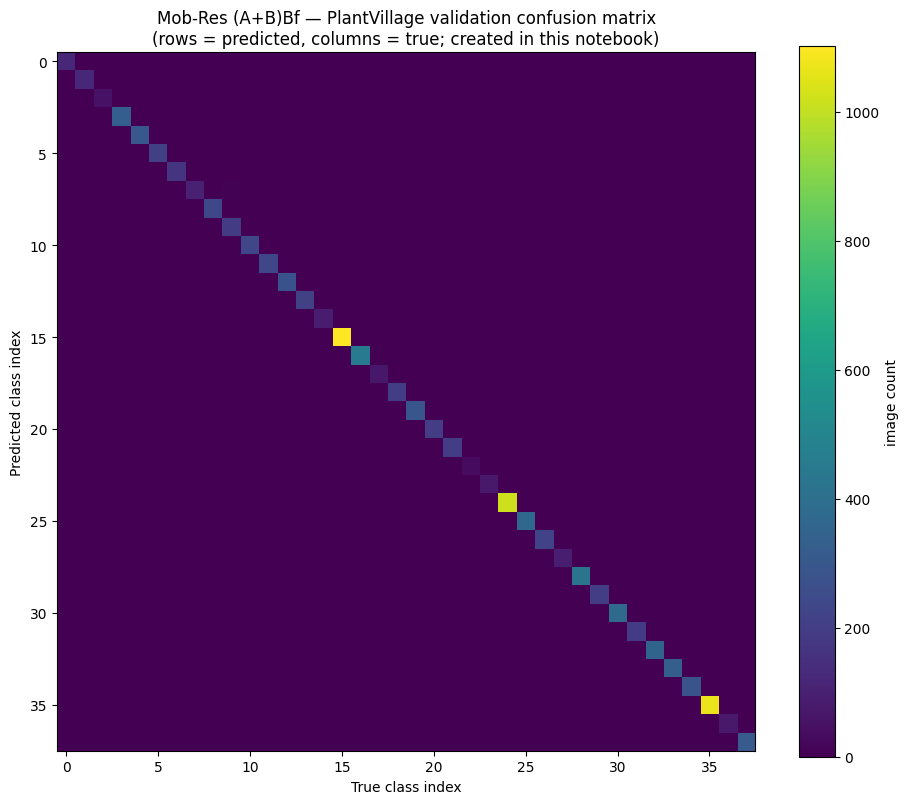

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(cm, cmap="viridis", aspect="equal")
ax.set_title("Mob-Res (A+B)Bf — PlantVillage validation confusion matrix\n(rows = predicted, columns = true; created in this notebook)")
ax.set_xlabel("True class index")
ax.set_ylabel("Predicted class index")
fig.colorbar(im, ax=ax, label="image count")
plt.tight_layout()
plt.show()


### Per-class results table and CSV export

Show the classes with the most misclassifications plus a compact per-class table, and export the full table to `/content/mobres_validation_per_class.csv` inside this Colab VM. **クラス別結果:** 誤分類の多いクラスを表示し、クラス別表を CSV に保存します（保存先はこの Colab VM 内です）。


In [ ]:
import pandas as pd
per_class = pd.DataFrame({
    "class": class_names,
    "support": cm.sum(axis=0).astype(int),
    "correct": np.diag(cm).astype(int),
    "misclassified": (cm.sum(axis=0) - np.diag(cm)).astype(int),
    "recall": recall,
    "precision": precision,
}).sort_values("misclassified", ascending=False)
print(per_class.head(10).to_string(index=False))
per_class.to_csv("/content/mobres_validation_per_class.csv", index=False)
print("\nfull table saved to /content/mobres_validation_per_class.csv",
      f"({len(per_class)} rows)")


                                   class  support  correct  misclassified   recall  precision
     Corn_(maize)___Northern_Leaf_Blight      197      191              6 0.969543        1.0
  Tomato___Tomato_Yellow_Leaf_Curl_Virus     1071     1069              2 0.998133        1.0
                   Tomato___Early_blight      200      199              1 0.995000        1.0
                Apple___Cedar_apple_rust       55       55              0 1.000000        1.0
                      Apple___Apple_scab      126      126              0 1.000000        1.0
                       Apple___Black_rot      125      125              0 1.000000        1.0
Cherry_(including_sour)___Powdery_mildew      210      210              0 1.000000        1.0
                     Blueberry___healthy      300      300              0 1.000000        1.0
                         Apple___healthy      329      329              0 1.000000        1.0
       Cherry_(including_sour)___healthy      170      170  

### Grad-CAM on the paper's named layers (single example, re-implementation)

The paper visualizes Grad-CAM at **Path1 layer 27** — which in the released checkpoint is exactly index 27, `re_lu_5_3`, the final Path1 ReLU (verified by layer enumeration) — and **Path2 `out_relu`** (index 153 of the flattened graph) inside the nested MobileNetV2. The authors released no XAI scripts, so this is an **AI-generated re-implementation** following the paper's layer specification, on one correctly classified validation image (first image, `Apple___Apple_scab`). **Grad-CAM:** 論文が指定する層（Path1 の第 27 層 ReLU＝`re_lu_5_3`、Path2 の `out_relu`）で 1 枚の検証画像に Grad-CAM を再実装します（著者の XAI スクリプトは未公開のため AI による再実装です）。


In [ ]:
import tensorflow as tf

p1_relu = [l for l in model.layers if l.__class__.__name__ == "ReLU"][-1]
assert p1_relu.name == "re_lu_5_3", p1_relu.name
mnv = model.get_layer("mobilenetv2_1.00_128_3")
p2_relu = mnv.get_layer("out_relu")
gaps = [l for l in model.layers if l.__class__.__name__ == "GlobalAveragePooling2D"]
gap1 = [g for g in gaps if g.input_shape[-1] == 256][0]
gap2 = [g for g in gaps if g.input_shape[-1] == 1280][0]
concat_l = [l for l in model.layers if l.__class__.__name__ == "Concatenate"][0]
dense_l = [l for l in model.layers if l.__class__.__name__ == "Dense"][0]
p1_model = tf_keras.Model(model.input, p1_relu.output)

def gradcam(x_t, act_model, act_gap, cls_idx):
    # Gradient of the class score w.r.t. the named activation, through the
    # actual GAP -> concatenate -> dense head of the loaded checkpoint.
    with tf.GradientTape() as tape:
        act = act_model(x_t, training=False)
        tape.watch(act)
        other = (mnv(x_t, training=False) if act_gap is gap1
                 else p1_model(x_t, training=False))
        other_gap = gap2 if act_gap is gap1 else gap1
        feats = concat_l([act_gap(act), other_gap(other)])
        score = dense_l(feats)[:, cls_idx]
    g = tape.gradient(score, act)
    w = tf.reduce_mean(g, axis=[0, 1, 2])
    cam = tf.reduce_sum(act[0] * w, axis=-1)
    return (tf.nn.relu(cam) / (tf.reduce_max(cam) + 1e-8)).numpy()

x1 = imgs[:1]
cls1 = int(labs[0])
cam1 = gradcam(x1, p1_model, gap1, cls1)
cam2 = gradcam(x1, mnv, gap2, cls1)
print("sample:", class_names[cls1], "| cam1", cam1.shape, "| cam2", cam2.shape)


sample: Apple___Apple_scab | cam1 (128, 128) | cam2 (4, 4)


### Grad-CAM overlay figure

Overlay both paths' heatmaps on the input image. This is a notebook-created visualization, not an author figure. **Grad-CAM の重ね合わせ:** 両経路のヒートマップを入力画像に重ねて表示します（このノートブックで作成した図であり、論文図の再掲ではありません）。


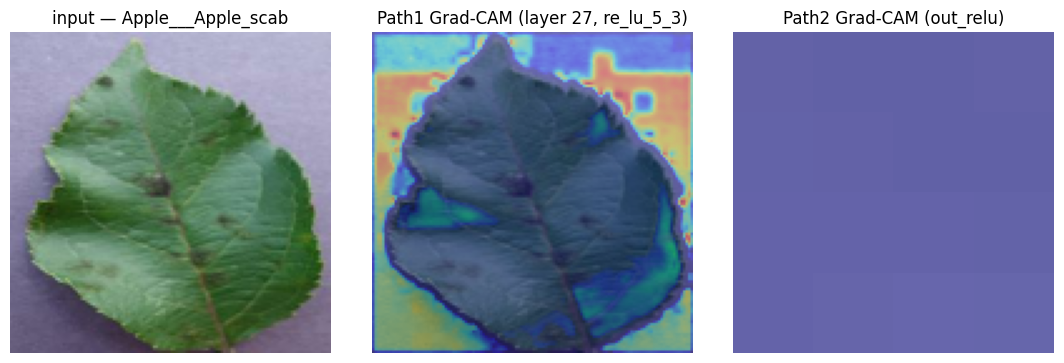

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
axes[0].imshow(x1[0].numpy().astype("uint8"))
axes[0].set_title(f"input — {class_names[cls1]}")
axes[1].imshow(x1[0].numpy().astype("uint8"))
axes[1].imshow(cam1, cmap="jet", alpha=0.4)
axes[1].set_title("Path1 Grad-CAM (layer 27, re_lu_5_3)")
axes[2].imshow(x1[0].numpy().astype("uint8"))
axes[2].imshow(cam2, cmap="jet", alpha=0.4)
axes[2].set_title("Path2 Grad-CAM (out_relu)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Interpretation, validation record, and references

- **What was executed:** the authors' exact validation procedure on their bundled 10,861-image PlantVillage split with their released (A+B)Bf checkpoint, on the runtime reported in the environment cell above. Compare the printed accuracy with the paper's **99.92%**; small deviations can come from framework version differences (TF 2.10 → current TF with `tf_keras`).
- **What this does not show:** this is a single-checkpoint validation of one configuration. It does not retrain anything, does not cover the other seven training strategies, the Kaggle Plant Disease Expert dataset, the sugarcane field experiment, or the benchmark comparisons, and a single-example Grad-CAM is illustrative only.
- **Adaptations (AI-generated, executed):** `tf-keras` install; `.keras`→`.h5` rename (file is legacy HDF5); pinned blob-free sparse clone inside Colab; Grad-CAM re-implementation at the paper's named layers.
- **Provenance:** Chiranjit369/Mob-Res @ `36d469b04fc3d3da58bb2cfdf89d4160ac38db01` (checkpoint sha256 printed above; 10,861 images asserted); paper DOI 10.1038/s41598-025-94083-1. No license file is present in the repository — reuse terms should be verified before any redistribution.
- **検証のまとめ（日本語）:** 著者同梱の 10,861 枚の検証画像と公開チェックポイントを用い、著者の手法どおりに正解率・マクロ適合率/再現率を計算しました。論文参照値 99.92% と出力を比較してください。再学習・他構成・Kaggle データ・サトウキビ実験は未検証です。Grad-CAM は 1 例のデモです。

**References:** Pal et al., Sci Rep 15, 30720 (2025) · Mob-Res repository (commit pinned above) · PlantVillage dataset (spMohanty/PlantVillage-Dataset).
